In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

### Converting to grayscale

In [2]:
img_path=cv2.imread(r"road.jpg")

In [3]:
def edge_detect(img_path):
    img=cv2.cvtColor(img_path,cv2.COLOR_BGR2RGB)
    img_gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    # Applying blur
    img_blur=cv2.GaussianBlur(img_gray,(5,5),0)
    # Edge Detection
    img_edge=cv2.Canny(img_blur,150,250)
    return img_edge

In [4]:
img_edge=edge_detect(img_path)

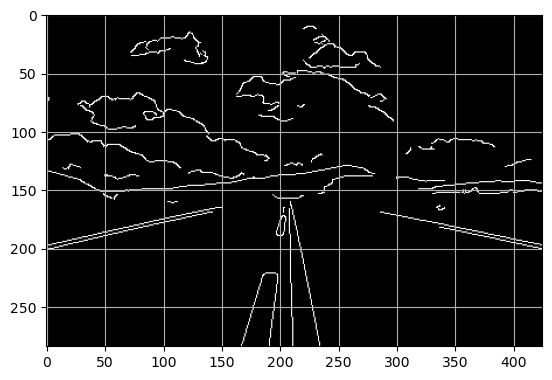

In [5]:
plt.imshow(img_edge,cmap='gray')
plt.grid()

In [6]:
def Return_of_interest(img_edge):
    height,width=img_edge.shape
    mask=np.zeros_like(img_edge)
    polygon=np.array([[
        (0,height),
        (width,height),
        (width,190),
        (325,165),
        (100,165),
        (0,190)
        
    ]],np.int32)
    cv2.fillPoly(mask,polygon,255)
    roi=cv2.bitwise_and(img_edge,mask)
    return roi

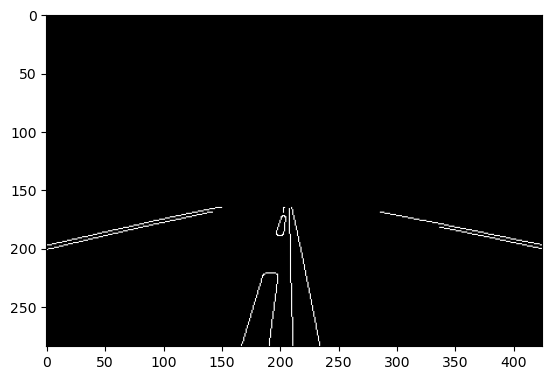

In [7]:
plt.imshow(Return_of_interest(img_edge),cmap='gray')

In [8]:
# Using Houghlines to detect lanes 
roi=Return_of_interest(img_edge)
def hough_lines(roi):
    lines=cv2.HoughLinesP(roi,3,np.pi/180,50,minLineLength=20,maxLineGap=38)
    img1=cv2.cvtColor(img_path,cv2.COLOR_BGR2RGB).copy()
    img_cp=np.zeros_like(img_path)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2=line[0]
            cv2.line(img_cp,(x1,y1),(x2,y2),(0,0,255),2)
    combo_img=cv2.addWeighted(img1,0.8,img_cp,1,1)
    return combo_img

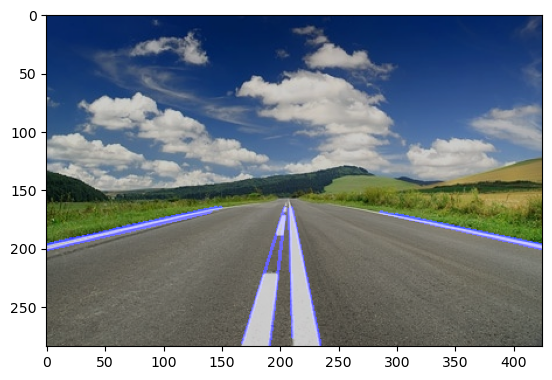

In [9]:
plt.imshow(hough_lines(roi))